In [2]:

import pandas as pd
import xarray as xr
import numpy as np
import os
import matplotlib.pyplot as plt
from ooinet import M2M

In [3]:
ctd = xr.open_dataset("data/gs01sumo_nsif_ctd.nc")
dosta = xr.open_dataset("data/gs01sumo_nsif_dosta.nc")

INFO:httpx:HTTP Request: GET https://raw.githubusercontent.com/IrishMarineInstitute/awesome-erddap/master/erddaps.json "HTTP/1.1 200 OK"


In [4]:
# Clean up the datasets
ctd_keep = [v for v in ctd.data_vars if "qc" not in v and 'qartod' not in v]
ctd = ctd[ctd_keep]

dosta_keep = [v for v in dosta.data_vars if "qc" not in v and 'qartod' not in v]
dosta = dosta[dosta_keep]

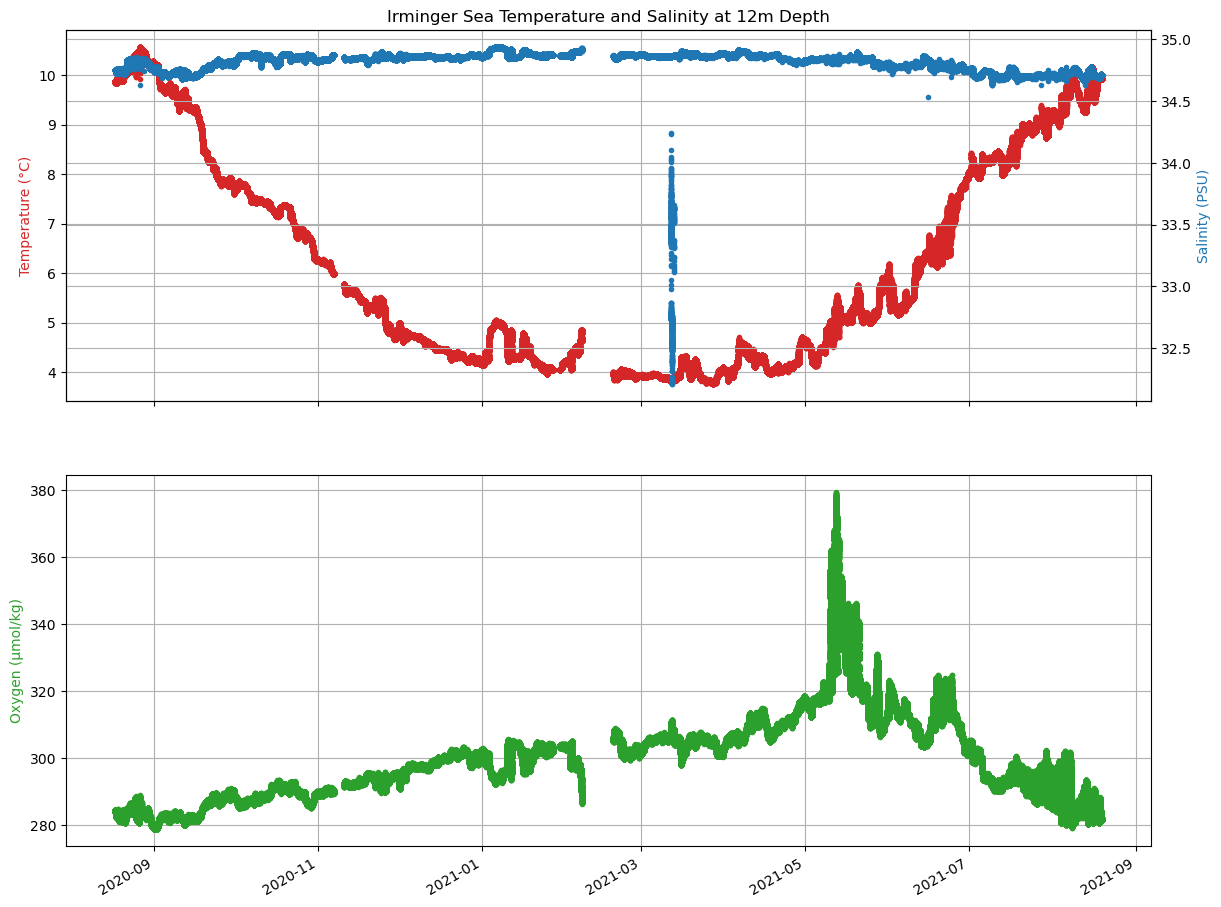

In [5]:
# Plot some of the data
# First plot the temperature and salinity from the CTD data set.
fig, (ax, axb) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

ax.plot(ctd['time'], ctd['sea_water_temperature'], color='tab:red', linestyle='', marker= '.', label='Temperature (°C)')
ax.set_ylabel('Temperature (°C)', color='tab:red')
ax.set_title('Irminger Sea Temperature and Salinity at 12m Depth')

ax2 = ax.twinx()
ax2.plot(ctd['time'], ctd['sea_water_practical_salinity'], color='tab:blue', linestyle='', marker='.', label='Salinity (PSU)')
ax2.set_ylabel('Salinity (PSU)', color='tab:blue')

ax.grid()
ax2.grid()

axb.plot(dosta['time'], dosta['oxygen_concentration_corrected'], color='tab:green', linestyle='', marker='.', label='Oxygen (µmol/kg)')
axb.set_ylabel('Oxygen (µmol/kg)', color='tab:green')
axb.grid()

fig.autofmt_xdate() # 

In [62]:
ctd['sea_water_practical_salinity'].max()

<xarray.DataArray 'sea_water_practical_salinity' ()> Size: 8B
array(34.93714375)
Attributes:
    comment:                   Salinity is generally defined as the concentra...
    long_name:                 Practical Salinity
    data_product_identifier:   PRACSAL_L2
    standard_name:             sea_water_practical_salinity
    units:                     1
    ancillary_variables:       practical_salinity_qartod_results practical_sa...
    alternate_parameter_name:  practical_salinity

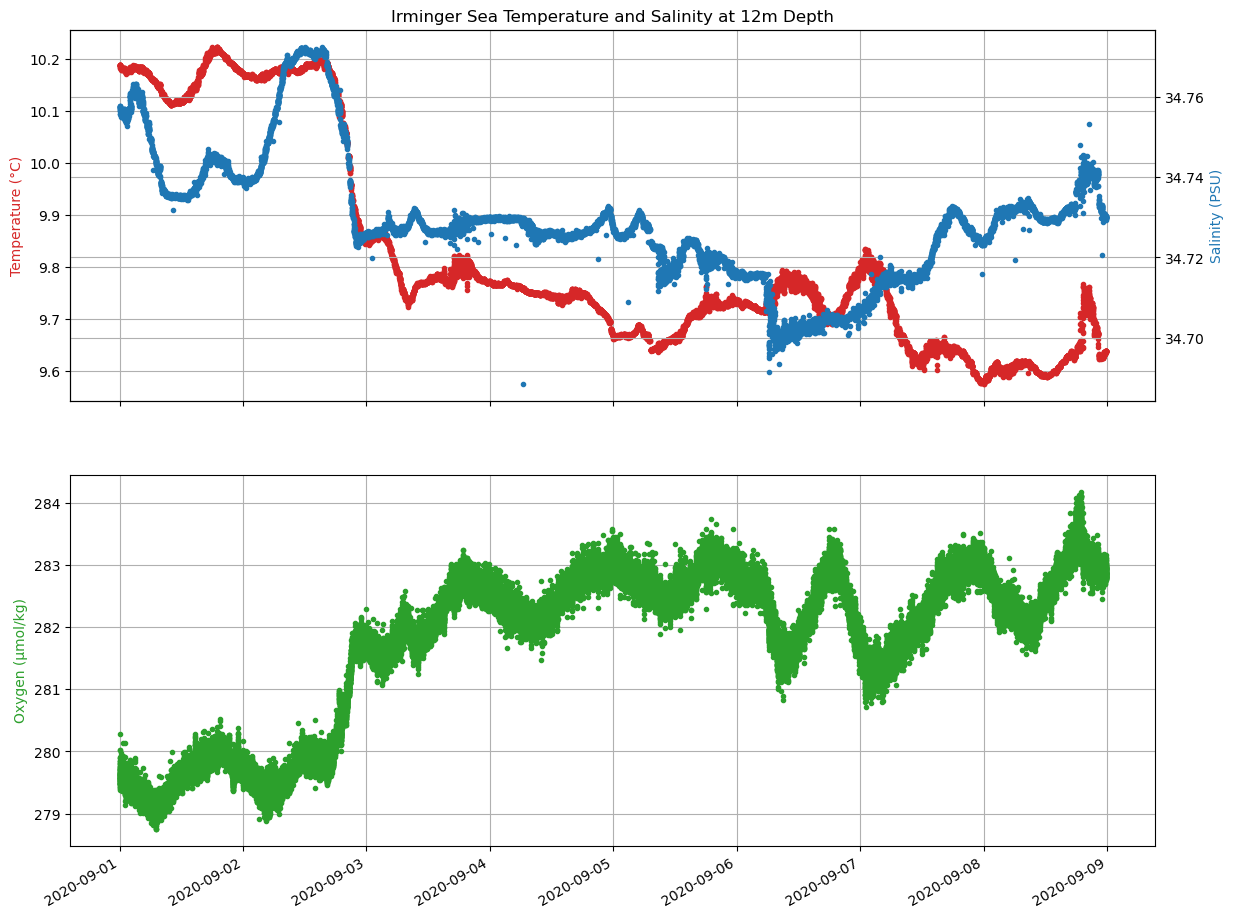

In [6]:
# Zoom in a week's worth of data
# First plot the temperature and salinity from the CTD data set.
fig, (ax, axb) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

t1 = '2020-09-01'
t2 = '2020-09-08'

ax.plot(ctd['time'].sel(time=slice(t1, t2)), ctd['sea_water_temperature'].sel(time=slice(t1, t2)), color='tab:red', linestyle='', marker= '.', label='Temperature (°C)')
ax.set_ylabel('Temperature (°C)', color='tab:red')
ax.set_title('Irminger Sea Temperature and Salinity at 12m Depth')

ax2 = ax.twinx()
ax2.plot(ctd['time'].sel(time=slice(t1, t2)), ctd['sea_water_practical_salinity'].sel(time=slice(t1, t2)), color='tab:blue', linestyle='', marker='.', label='Salinity (PSU)')
ax2.set_ylabel('Salinity (PSU)', color='tab:blue')

ax.grid()
ax2.grid()

axb.plot(dosta['time'].sel(time=slice(t1, t2)), dosta['oxygen_concentration_corrected'].sel(time=slice(t1, t2)), color='tab:green', linestyle='', marker='.', label='Oxygen (µmol/kg)')
axb.set_ylabel('Oxygen (µmol/kg)', color='tab:green')
axb.grid()

fig.autofmt_xdate()

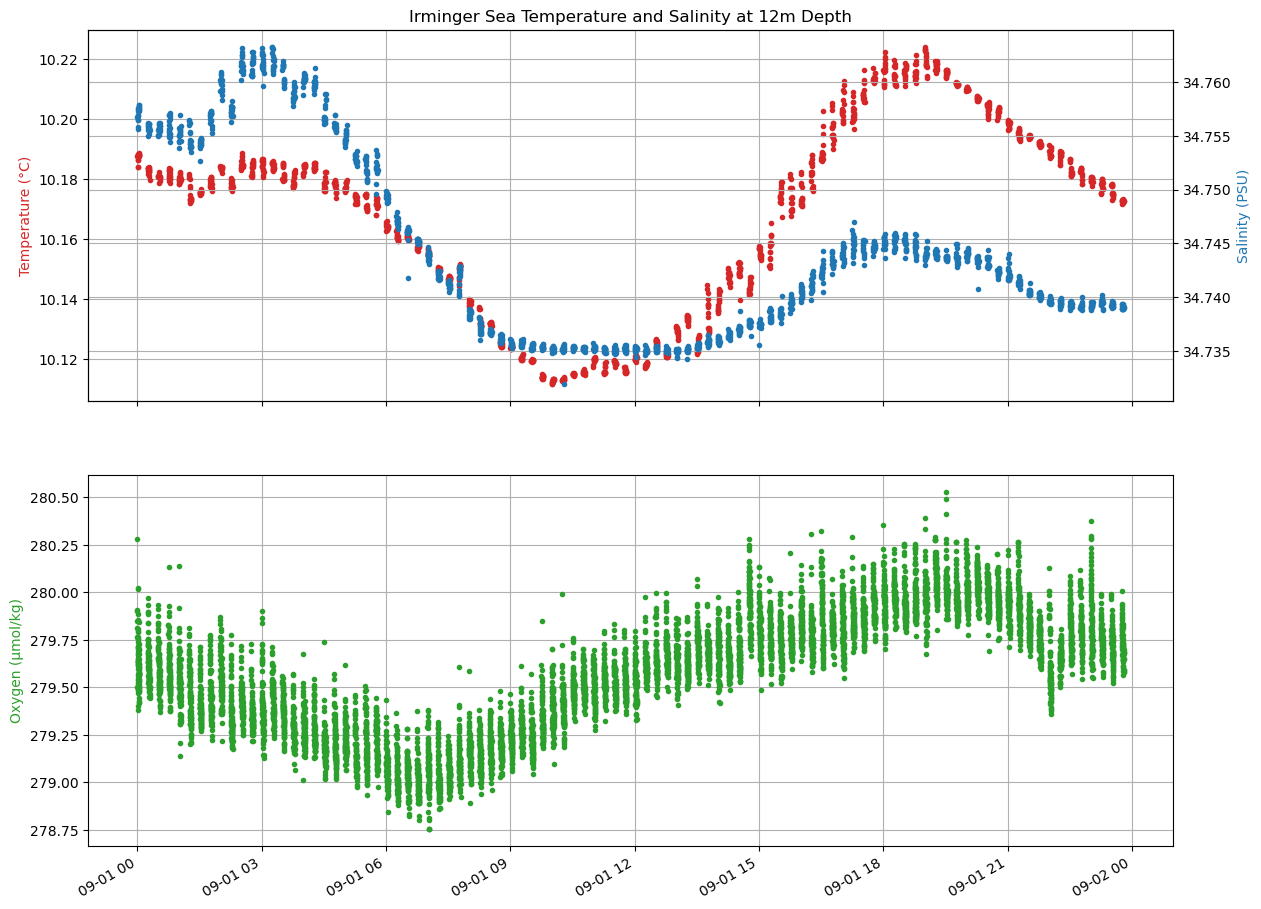

In [7]:
# Zoom in a day's worth of data
# First plot the temperature and salinity from the CTD data set.
fig, (ax, axb) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

t1 = '2020-09-01'
t2 = '2020-09-01'

ax.plot(ctd['time'].sel(time=slice(t1, t2)), ctd['sea_water_temperature'].sel(time=slice(t1, t2)), color='tab:red', linestyle='', marker= '.', label='Temperature (°C)')
ax.set_ylabel('Temperature (°C)', color='tab:red')
ax.set_title('Irminger Sea Temperature and Salinity at 12m Depth')

ax2 = ax.twinx()
ax2.plot(ctd['time'].sel(time=slice(t1, t2)), ctd['sea_water_practical_salinity'].sel(time=slice(t1, t2)), color='tab:blue', linestyle='', marker='.', label='Salinity (PSU)')
ax2.set_ylabel('Salinity (PSU)', color='tab:blue')

ax.grid()
ax2.grid()

axb.plot(dosta['time'].sel(time=slice(t1, t2)), dosta['oxygen_concentration_corrected'].sel(time=slice(t1, t2)), color='tab:green', linestyle='', marker='.', label='Oxygen (µmol/kg)')
axb.set_ylabel('Oxygen (µmol/kg)', color='tab:green')
axb.grid()

fig.autofmt_xdate()

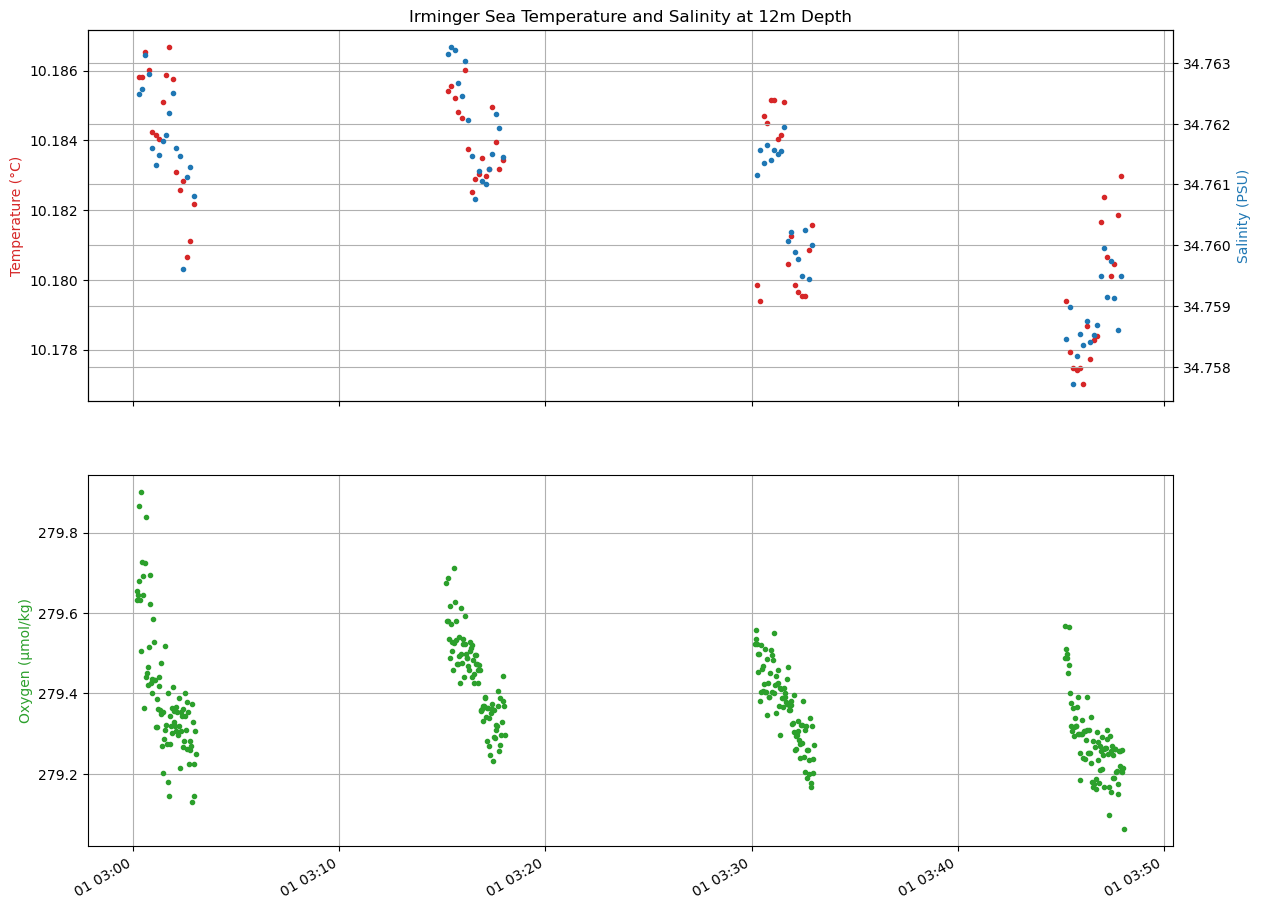

In [8]:
# Okay, so the data are collected in bursts. Lets look at 1-hour of data
# Zoom in a day's worth of data
# First plot the temperature and salinity from the CTD data set.
fig, (ax, axb) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

t1 = '2020-09-01T03:00:00'
t2 = '2020-09-01T04:00:00'

ax.plot(ctd['time'].sel(time=slice(t1, t2)), ctd['sea_water_temperature'].sel(time=slice(t1, t2)), color='tab:red', linestyle='', marker= '.', label='Temperature (°C)')
ax.set_ylabel('Temperature (°C)', color='tab:red')
ax.set_title('Irminger Sea Temperature and Salinity at 12m Depth')

ax2 = ax.twinx()
ax2.plot(ctd['time'].sel(time=slice(t1, t2)), ctd['sea_water_practical_salinity'].sel(time=slice(t1, t2)), color='tab:blue', linestyle='', marker='.', label='Salinity (PSU)')
ax2.set_ylabel('Salinity (PSU)', color='tab:blue')

ax.grid()
ax2.grid()

axb.plot(dosta['time'].sel(time=slice(t1, t2)), dosta['oxygen_concentration_corrected'].sel(time=slice(t1, t2)), color='tab:green', linestyle='', marker='.', label='Oxygen (µmol/kg)')
axb.set_ylabel('Oxygen (µmol/kg)', color='tab:green')
axb.grid()
fig.autofmt_xdate()

### Statistics and Resampling

So it looks like both the CTD and the DOSTA data collect in bursts every 15 minutes. This allows for strong statistics to be generated for each sample data point. So next we want to process the data to calculate the median and standard deviation for each burst of data

In [9]:
# First get the scalar variables for thd CTD
scalar_vars = [v for v in ctd.data_vars if ctd[v].dims == ('time',) and np.issubdtype(ctd[v].dtype, np.number)]

# Next, convert the scalar variables to a data frame (this is done bc the built in xarray groupby function is a loop that fallsback to pandas but is much slower on the roundtripping data sets)
ctd_df = ctd[scalar_vars].to_dataframe()
resampler = ctd_df.resample('900s', origin='start_day', offset=pd.Timedelta('3150s'))
ctd_median = resampler.median()

# Now calculate the median absolute deviation
ctd_group_median = resampler.transform('median')
deviations = (ctd_df - ctd_group_median).abs()
ctd_mad = deviations.resample('900s', origin='start_day', offset=pd.Timedelta('3150s')).median()

ctd_stats = pd.concat([ctd_median, ctd_mad], axis=1, keys=['median', 'mad']).swaplevel(axis=1).sort_index(axis=1)
# Adjust back to the start of the sample period
ctd_stats.index = ctd_stats.index + pd.Timedelta('450s')  




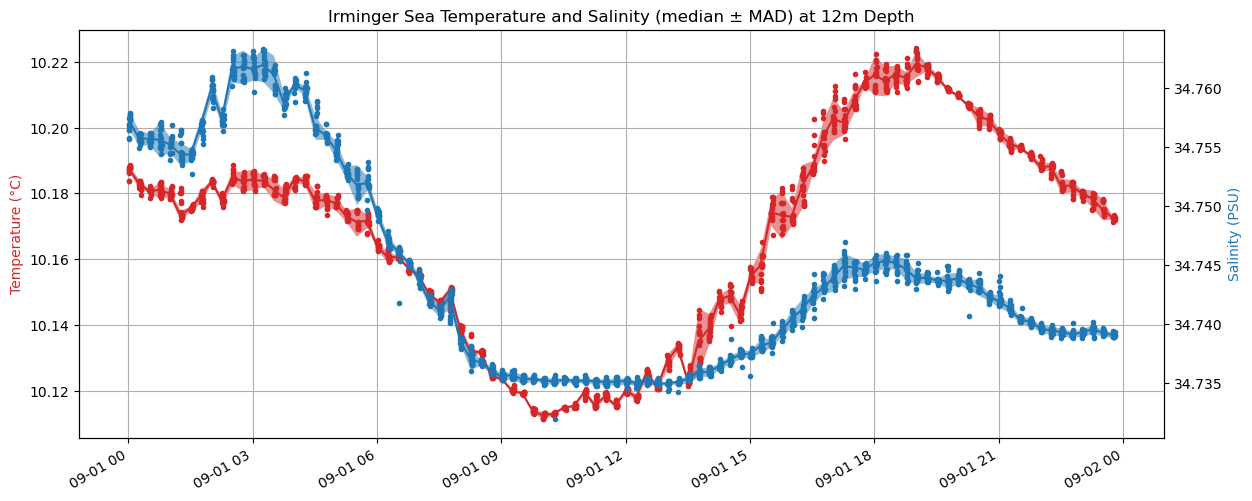

In [10]:
# Plot the resampled median temperature and salinity, with a shaded band
# for +/- 2 MAD around each median.
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

t1 = '2020-09-01'
t2 = '2020-09-01'

temp_median = ctd_stats['sea_water_temperature']['median'].loc[slice(t1, t2)]
temp_mad = ctd_stats['sea_water_temperature']['mad'].loc[slice(t1, t2)]

ax.plot(ctd['time'].sel(time=slice(t1, t2)), ctd['sea_water_temperature'].sel(time=slice(t1, t2)), color='tab:red', linestyle='', marker= '.', label='Temperature (°C)')

ax.set_ylabel('Temperature (°C)', color='tab:red')
ax.set_title('Irminger Sea Temperature and Salinity at 12m Depth')


ax.plot(temp_median.index, temp_median, color='tab:red', label='Temperature (°C)')
ax.fill_between(temp_median.index, temp_median - 2*temp_mad, temp_median + 2*temp_mad,
                 color='tab:red', alpha=0.5, linewidth=0, label='±1 MAD')
ax.set_ylabel('Temperature (°C)', color='tab:red')
ax.set_title('Irminger Sea Temperature and Salinity (median ± MAD) at 12m Depth')

ax2 = ax.twinx()
sal_median = ctd_stats['sea_water_practical_salinity']['median'].loc[slice(t1, t2)]
sal_mad = ctd_stats['sea_water_practical_salinity']['mad'].loc[slice(t1, t2)]
ax2.plot(ctd['time'].sel(time=slice(t1, t2)), ctd['sea_water_practical_salinity'].sel(time=slice(t1, t2)), color='tab:blue', linestyle='', marker='.', label='Salinity (PSU)')
ax2.plot(sal_median.index, sal_median, color='tab:blue', label='Salinity (PSU)')
ax2.fill_between(sal_median.index, sal_median - 2*sal_mad, sal_median + 2*sal_mad,
                  color='tab:blue', alpha=0.5, linewidth=0, label='±1 MAD')
ax2.set_ylabel('Salinity (PSU)', color='tab:blue')

ax.grid()
fig.autofmt_xdate()

In [11]:
# Identify gaps in the resampled median series.
# df.resample() already produces one row per 900s bin across the full time
# range, so a "gap" (a burst with no data) shows up as a NaN in df_stats
# rather than a missing timestamp.
medians = ctd_stats.xs('median', axis=1, level=1)

gap_counts = medians.isna().sum()
print("Missing burst-median values per variable:")
print(gap_counts)

Missing burst-median values per variable:
deployment                           1699
depth                                1699
raw_pressure_temperature             1699
raw_seawater_conductivity            1699
raw_seawater_pressure                1699
raw_seawater_temperature             1699
sea_water_density                    1699
sea_water_electrical_conductivity    1699
sea_water_practical_salinity         1699
sea_water_pressure                   1699
sea_water_temperature                1699
dtype: int64


In [12]:
# Fill gaps with a linear trend + two-harmonic fit.
#
# Model: y(t) = a0 + a1*t + A1*cos(w1*t) + B1*sin(w1*t) + A2*cos(w2*t) + B2*sin(w2*t)
# This is linear in its coefficients, so it's fit with ordinary least squares
# on the non-gap points, then evaluated everywhere to fill the gaps.
#
# Default periods are 365.25d and 182.625d (annual + semiannual seasonal
# cycles).
def fill_harmonic_gaps(series, periods=('365.25d', '182.625d')):
    t = (series.index - series.index[0]) / pd.Timedelta('1s')
    omegas = [2 * np.pi / (pd.Timedelta(p) / pd.Timedelta('1s')) for p in periods]

    X = np.column_stack([
        np.ones_like(t),
        t,
        *[f(omega * t) for omega in omegas for f in (np.cos, np.sin)],
    ])

    valid = series.notna().values
    coeffs, *_ = np.linalg.lstsq(X[valid], series.values[valid], rcond=None)

    fitted = pd.Series(X @ coeffs, index=series.index)
    filled = series.where(valid, fitted)
    return filled, fitted

In [13]:
# Apply the fill to every median column, keeping track of which points were
# gap-filled (vs. originally observed) for downstream QC/plotting.
filled_ctd = medians.copy()
was_filled = medians.isna()

for col in medians.columns:
    filled_ctd[col], _ = fill_harmonic_gaps(medians[col])

filled_ctd

,deployment,depth,raw_pressure_temperature,raw_seawater_conductivity,raw_seawater_pressure,raw_seawater_temperature,sea_water_density,sea_water_electrical_conductivity,sea_water_practical_salinity,sea_water_pressure,sea_water_temperature
time,,,,,,,,,,,
2020-08-17 17:45:00,7.0,11.716655,16005.0,1419862.0,590515.0,410548.0,1026.837984,3.772250,34.750132,11.828438,9.864621
2020-08-17 18:00:00,7.0,12.047414,16007.0,1419893.0,591517.0,410535.0,1026.838707,3.772460,34.750044,12.162362,9.865473
2020-08-17 18:15:00,7.0,12.347831,16005.0,1419921.0,592427.0,410488.0,1026.838420,3.772649,34.748848,12.465655,9.868555
2020-08-17 18:30:00,7.0,12.241149,16005.0,1419903.0,592104.0,410499.0,1026.837977,3.772527,34.748303,12.357951,9.867833
2020-08-17 18:45:00,7.0,12.123914,16004.0,1419875.0,591749.0,410521.0,1026.836840,3.772338,34.748249,12.239594,9.866391
...,...,...,...,...,...,...,...,...,...,...,...
2021-08-19 05:45:00,7.0,12.478374,16024.0,1420284.0,592822.0,409528.0,1026.800584,3.775100,34.713366,12.597447,9.931559
2021-08-19 06:00:00,7.0,12.479333,16023.0,1420234.0,592825.0,409572.0,1026.800488,3.774763,34.712596,12.598415,9.928669
2021-08-19 06:15:00,7.0,12.493485,16020.0,1420169.0,592868.0,409644.0,1026.801460,3.774324,34.712747,12.612703,9.923940


In [37]:
was_filled

,deployment,depth,raw_pressure_temperature,raw_seawater_conductivity,raw_seawater_pressure,raw_seawater_temperature,sea_water_density,sea_water_electrical_conductivity,sea_water_practical_salinity,sea_water_pressure,sea_water_temperature
time,,,,,,,,,,,
2020-08-17 17:45:00,False,False,False,False,False,False,False,False,False,False,False
2020-08-17 18:00:00,False,False,False,False,False,False,False,False,False,False,False
2020-08-17 18:15:00,False,False,False,False,False,False,False,False,False,False,False
2020-08-17 18:30:00,False,False,False,False,False,False,False,False,False,False,False
2020-08-17 18:45:00,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
2021-08-19 05:45:00,False,False,False,False,False,False,False,False,False,False,False
2021-08-19 06:00:00,False,False,False,False,False,False,False,False,False,False,False
2021-08-19 06:15:00,False,False,False,False,False,False,False,False,False,False,False


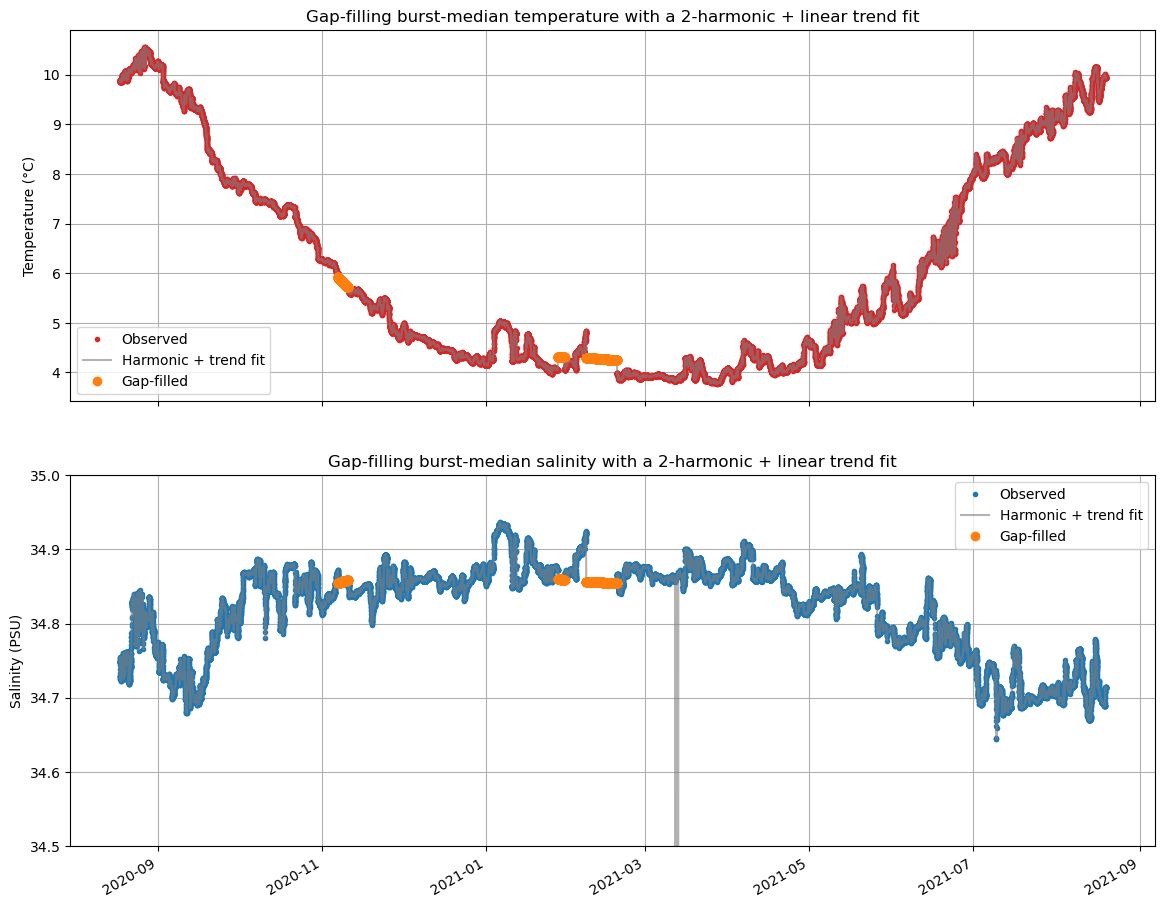

In [14]:
# Sanity-check the fill for temperature: observed values as dots, the
# harmonic+trend fit as a line, and the gap-filled points highlighted.
fig, (ax, axb) = plt.subplots(2, 1, figsize=(14, 12))

var = 'sea_water_temperature'
filled_mask = was_filled[var]

ax.plot(medians.index, medians[var], color='tab:red', linestyle='', marker='.', label='Observed')
ax.plot(filled_ctd.index, filled_ctd[var], color='tab:gray', alpha=0.6, label='Harmonic + trend fit')
ax.plot(filled_ctd.index[filled_mask], filled_ctd[var][filled_mask],
        color='tab:orange', linestyle='', marker='o', label='Gap-filled')

ax.set_ylabel('Temperature (°C)')
ax.set_title('Gap-filling burst-median temperature with a 2-harmonic + linear trend fit')
ax.legend()
ax.grid()

var = 'sea_water_practical_salinity'
filled_mask = was_filled[var]

axb.plot(medians.index, medians[var], color='tab:blue', linestyle='', marker='.', label='Observed')
axb.plot(filled_ctd.index, filled_ctd[var], color='tab:gray', alpha=0.6, label='Harmonic + trend fit')
axb.plot(filled_ctd.index[filled_mask], filled_ctd[var][filled_mask],
        color='tab:orange', linestyle='', marker='o', label='Gap-filled')

axb.set_ylabel('Salinity (PSU)')
axb.set_ylim(34.5, 35.0)
axb.set_title('Gap-filling burst-median salinity with a 2-harmonic + linear trend fit')
axb.legend()
axb.grid()

fig.autofmt_xdate()

##### Repeat the calculations for oxygen sensor

In [15]:
# First get the scalar variables for thd DOSTA
scalar_vars = [v for v in dosta.data_vars if dosta[v].dims == ('time',) and np.issubdtype(dosta[v].dtype, np.number)]

# Next, convert the scalar variables to a data frame (this is done bc the built in xarray groupby function is a loop that fallsback to pandas but is much slower on the roundtripping data sets)
dosta_df = dosta[scalar_vars].to_dataframe()
resampler = dosta_df.resample('900s', origin='start_day', offset=pd.Timedelta('3150s'))
dosta_median = resampler.median()

# Now calculate the median absolute deviation
dosta_group_median = resampler.transform('median')
deviations = (dosta_df - dosta_group_median).abs()
dosta_mad = deviations.resample('900s', origin='start_day', offset=pd.Timedelta('3150s')).median()

dosta_stats = pd.concat([dosta_median, dosta_mad], axis=1, keys=['median', 'mad']).swaplevel(axis=1).sort_index(axis=1)
# Adjust back to the start of the sample period
dosta_stats.index = dosta_stats.index + pd.Timedelta('450s')  

In [16]:
# Identify gaps in the resampled dosta median series.
# df.resample() already produces one row per 900s bin across the full time
# range, so a "gap" (a burst with no data) shows up as a NaN in df_stats
# rather than a missing timestamp.
dosta_medians = dosta_stats.xs('median', axis=1, level=1)

gap_counts = dosta_medians.isna().sum()
print("Missing burst-median values per variable:")
print(gap_counts)

Missing burst-median values per variable:
blue_amplitude                    1849
blue_phase                        1849
calibrated_phase                  1849
deployment                        1699
depth                             1699
optode_temperature                1849
oxygen_concentration              1849
oxygen_concentration_corrected    1849
oxygen_saturation                 1849
raw_temperature                   1849
red_amplitude                     1849
red_phase                         1849
sea_water_practical_salinity      1699
sea_water_pressure                1849
sea_water_temperature             1699
svu_oxygen_concentration          1849
temp_compensated_phase            1849
dtype: int64


In [17]:
# Apply the fill to every median column, keeping track of which points were
# gap-filled (vs. originally observed) for downstream QC/plotting.
dosta_filled = dosta_medians.copy()
dosta_was_filled = dosta_medians.isna()

for col in dosta_medians.columns:
    dosta_filled[col], _ = fill_harmonic_gaps(dosta_medians[col])

dosta_filled

,blue_amplitude,blue_phase,calibrated_phase,deployment,depth,optode_temperature,oxygen_concentration,oxygen_concentration_corrected,oxygen_saturation,raw_temperature,red_amplitude,red_phase,sea_water_practical_salinity,sea_water_pressure,sea_water_temperature,svu_oxygen_concentration,temp_compensated_phase
time,,,,,,,,,,,,,,,,,
2020-08-17 17:45:00,737.299988,40.464500,31.969999,7.0,12.023825,9.8645,364.207001,284.305761,102.962997,445.399994,759.250000,8.492500,34.739290,12.204440,9.876349,364.198875,31.969999
2020-08-17 18:00:00,736.700012,40.464001,31.973000,7.0,12.138842,9.8680,364.075989,284.219234,102.933998,445.299988,758.799988,8.492000,34.734603,12.264387,9.875971,364.077119,31.973000
2020-08-17 18:15:00,736.000000,40.467999,31.976999,7.0,12.408300,9.8700,363.907990,284.095876,102.894997,445.299988,758.299988,8.491000,34.738519,12.530970,9.876778,363.910522,31.976999
2020-08-17 18:30:00,735.099976,40.469501,31.978001,7.0,12.259699,9.8700,363.880493,284.073104,102.886505,445.299988,758.349976,8.492000,34.724073,12.382251,9.885625,363.880156,31.978001
2020-08-17 18:45:00,734.799988,40.472000,31.980000,7.0,12.242437,9.8680,363.847992,284.037177,102.874496,445.299988,757.849976,8.491000,34.737586,12.363390,9.875000,363.842140,31.980000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-19 05:45:00,682.500000,40.424999,32.055000,7.0,12.377681,9.9360,360.570007,281.594709,102.109001,443.100006,714.400024,8.370000,34.706050,12.487532,10.017241,360.564086,32.055000
2021-08-19 06:00:00,682.299988,40.419498,32.049000,7.0,12.326140,9.9340,360.766510,281.775745,102.163498,443.200012,714.400024,8.370501,34.700001,12.404122,10.047997,360.759202,32.049000
2021-08-19 06:15:00,682.599976,40.425999,32.053001,7.0,12.225270,9.9290,360.713013,281.682519,102.138000,443.399994,714.500000,8.372000,34.709600,12.334112,9.984467,360.713868,32.053001


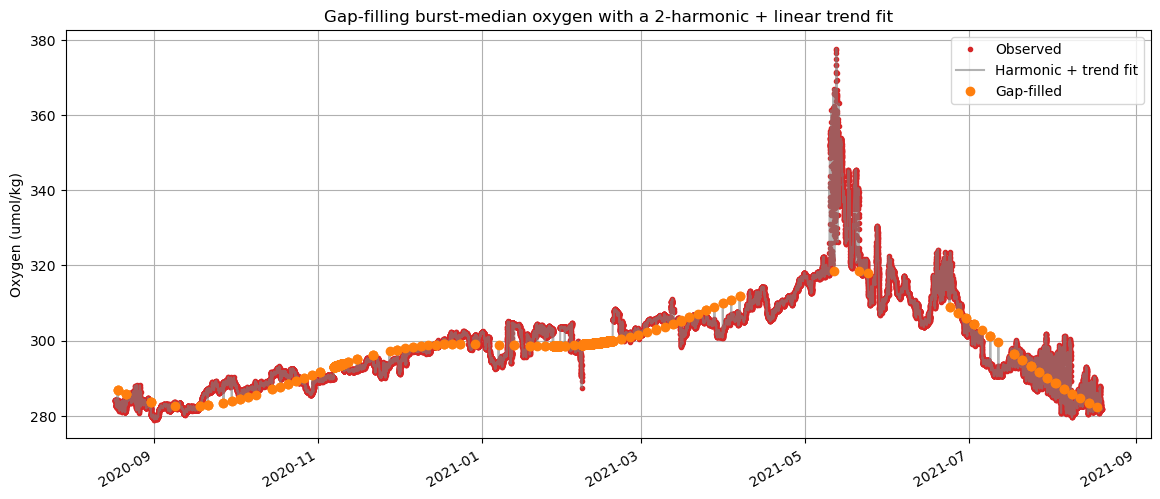

In [18]:
# Sanity-check the fill for temperature: observed values as dots, the
# harmonic+trend fit as a line, and the gap-filled points highlighted.
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

var = 'oxygen_concentration_corrected'
filled_mask = dosta_was_filled[var]

ax.plot(dosta_medians.index, dosta_medians[var], color='tab:red', linestyle='', marker='.', label='Observed')
ax.plot(dosta_filled.index, dosta_filled[var], color='tab:gray', alpha=0.6, label='Harmonic + trend fit')
ax.plot(dosta_filled.index[filled_mask], dosta_filled[var][filled_mask],
        color='tab:orange', linestyle='', marker='o', label='Gap-filled')

ax.set_ylabel('Oxygen (umol/kg)')
ax.set_title('Gap-filling burst-median oxygen with a 2-harmonic + linear trend fit')
ax.legend()
ax.grid()

fig.autofmt_xdate()

In [19]:
# Generate a modeled dataset
observed = pd.merge(ctd_stats.xs('median', axis=1, level=1)[['sea_water_temperature', 'sea_water_practical_salinity']], dosta_stats.xs('median', axis=1, level=1)[['oxygen_concentration_corrected']], left_index=True, right_index=True)
observed 

,sea_water_temperature,sea_water_practical_salinity,oxygen_concentration_corrected
time,,,
2020-08-17 17:45:00,9.864621,34.750132,284.305761
2020-08-17 18:00:00,9.865473,34.750044,284.219234
2020-08-17 18:15:00,9.868555,34.748848,284.095876
2020-08-17 18:30:00,9.867833,34.748303,284.073104
2020-08-17 18:45:00,9.866391,34.748249,284.037177
...,...,...,...
2021-08-19 05:45:00,9.931559,34.713366,281.594709
2021-08-19 06:00:00,9.928669,34.712596,281.775745
2021-08-19 06:15:00,9.923940,34.712747,281.682519


In [20]:
# Generate a modeled dataset (linear trend + annual/semiannual harmonic fit)
# for temperature, salinity, and oxygen so it can be plotted against the
# observations. 

modeled = pd.DataFrame(index=observed.index)

for col in observed.columns:
    _, modeled[col] = fill_harmonic_gaps(observed[col])

modeled

,sea_water_temperature,sea_water_practical_salinity,oxygen_concentration_corrected
time,,,
2020-08-17 17:45:00,9.962207,34.755122,287.076120
2020-08-17 18:00:00,9.962191,34.755123,287.072727
2020-08-17 18:15:00,9.962175,34.755124,287.069336
2020-08-17 18:30:00,9.962159,34.755126,287.065946
2020-08-17 18:45:00,9.962142,34.755127,287.062557
...,...,...,...
2021-08-19 05:45:00,9.478317,34.703283,281.851439
2021-08-19 06:00:00,9.478277,34.703284,281.848190
2021-08-19 06:15:00,9.478236,34.703286,281.844943


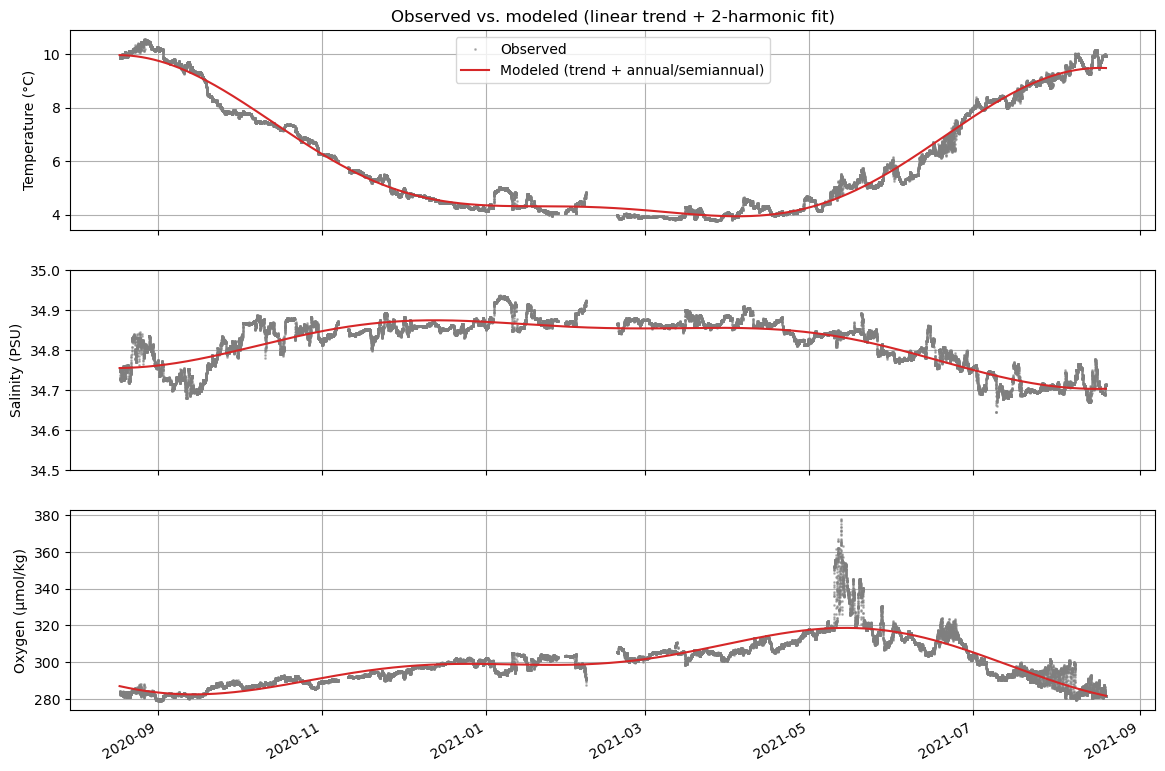

In [21]:
# Plot observed vs. modeled for all three variables.
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

labels = {
    'sea_water_temperature': 'Temperature (°C)',
    'sea_water_practical_salinity': 'Salinity (PSU)',
    'oxygen_concentration_corrected': 'Oxygen (µmol/kg)',
}

for ax, col in zip(axes, observed.columns):
    ax.plot(observed.index, observed[col], color='tab:gray', linestyle='',
             marker='.', markersize=2, alpha=0.5, label='Observed')
    ax.plot(modeled.index, modeled[col], color='tab:red', linewidth=1.5,
             label='Modeled (trend + annual/semiannual)')
    if 'sal' in col:
        ax.set_ylim(34.5, 35.0)
    ax.set_ylabel(labels[col])
    ax.grid()

axes[0].legend()
axes[0].set_title('Observed vs. modeled (linear trend + 2-harmonic fit)')
fig.autofmt_xdate()

### Save the reprocessed data with the median-absolute-deviations, noting which values are modeled and which are actual data

gs01sumo_nsif_dosta

In [59]:
# Start with CTD data
# Add the modeled flag
for col in ctd_stats.xs('median', axis=1, level=1).columns:
    ctd_stats[(col, 'modeled_flag')] = was_filled[col].astype(int)

# Next, we want to get just the set of key observations and not the full set of engineering data
key_observations = [
    'sea_water_temperature',
    'sea_water_practical_salinity',
    'deployment',
    'sea_water_pressure',
    'sea_water_density',
]

ctd_stats = ctd_stats.loc[:, key_observations]

# Now do the same for the DOSTA data
for col in dosta_stats.xs('median', axis=1, level=1).columns:
    dosta_stats[(col, 'modeled_flag')] = dosta_was_filled[col].astype(int)

# Next, we want to get just the set of key observations and not the full set of engineering data
key_observations = [
    'deployment',
    'oxygen_concentration_corrected',
    'oxygen_saturation'
]

dosta_stats = dosta_stats.loc[:, key_observations]

In [60]:
# Next we want to merge the two datasets
merged = pd.merge(ctd_stats, dosta_stats, left_index=True, right_index=True, how='outer')
merged

sea_water_temperature                         \
                                      mad    median modeled_flag   
time                                                               
2020-08-17 17:45:00              0.004523  9.864621            0   
2020-08-17 18:00:00              0.003147  9.865473            0   
2020-08-17 18:15:00              0.000393  9.868555            0   
2020-08-17 18:30:00              0.000918  9.867833            0   
2020-08-17 18:45:00              0.002885  9.866391            0   
...                                   ...       ...          ...   
2021-08-19 05:45:00              0.000131  9.931559            0   
2021-08-19 06:00:00              0.000591  9.928669            0   
2021-08-19 06:15:00              0.000525  9.923940            0   
2021-08-19 06:30:00              0.001051  9.931231            0   
2021-08-19 06:45:00              0.001051  9.924203            0   

                    sea_water_practical_salinity                          \
                                             mad     median modeled_flag   
time                                                                       
2020-08-17 17:45:00                     0.000501  34.750132            0   
2020-08-17 18:00:00                     0.000330  34.750044            0   
2020-08-17 18:15:00                     0.000105  34.748848            0   
2020-08-17 18:30:00                     0.000190  34.748303            0   
2020-08-17 18:45:00                     0.000463  34.748249            0   
...                                          ...        ...          ...   
2021-08-19 05:45:00                     0.000150  34.713366            0   
2021-08-19 06:00:00                     0.000093  34.712596            0   
2021-08-19 06:15:00                     0.000087  34.712747            0   
2021-08-19 06:30:00                     0.000221  34.712771            0   
2021-08-19 06:45:00                     0.000197  34.712613            0   

                    deployment_x                     sea_water_pressure  ...  \
                             mad median modeled_flag                mad  ...   
time                                                                     ...   
2020-08-17 17:45:00          0.0    7.0            0           0.215943  ...   
2020-08-17 18:00:00          0.0    7.0            0           0.361517  ...   
2020-08-17 18:15:00          0.0    7.0            0           0.285307  ...   
2020-08-17 18:30:00          0.0    7.0            0           0.272287  ...   
2020-08-17 18:45:00          0.0    7.0            0           0.341647  ...   
...                          ...    ...          ...                ...  ...   
2021-08-19 05:45:00          0.0    7.0            0           0.119605  ...   
2021-08-19 06:00:00          0.0    7.0            0           0.124948  ...   
2021-08-19 06:15:00          0.0    7.0            0           0.127978  ...   
2021-08-19 06:30:00          0.0    7.0            0           0.176613  ...   
2021-08-19 06:45:00          0.0    7.0            0           0.149994  ...   

                    sea_water_density deployment_y                      \
                         modeled_flag          mad median modeled_flag   
time                                                                     
2020-08-17 17:45:00                 0          0.0    7.0            0   
2020-08-17 18:00:00                 0          0.0    7.0            0   
2020-08-17 18:15:00                 0          0.0    7.0            0   
2020-08-17 18:30:00                 0          0.0    7.0            0   
2020-08-17 18:45:00                 0          0.0    7.0            0   
...                               ...          ...    ...          ...   
2021-08-19 05:45:00                 0          0.0    7.0            0   
2021-08-19 06:00:00                 0          0.0    7.0            0   
2021-08-19 06:15:00                 0          0.0    7.0          

In [ ]:
# Next, flatten the 

,deployment,depth,raw_pressure_temperature,raw_seawater_conductivity,raw_seawater_pressure,raw_seawater_temperature,sea_water_density,sea_water_electrical_conductivity,sea_water_practical_salinity,sea_water_pressure,sea_water_temperature
time,,,,,,,,,,,
2020-08-17 17:45:00,0,0,0,0,0,0,0,0,0,0,0
2020-08-17 18:00:00,0,0,0,0,0,0,0,0,0,0,0
2020-08-17 18:15:00,0,0,0,0,0,0,0,0,0,0,0
2020-08-17 18:30:00,0,0,0,0,0,0,0,0,0,0,0
2020-08-17 18:45:00,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
2021-08-19 05:45:00,0,0,0,0,0,0,0,0,0,0,0
2021-08-19 06:00:00,0,0,0,0,0,0,0,0,0,0,0
2021-08-19 06:15:00,0,0,0,0,0,0,0,0,0,0,0


In [25]:
# First, need to convert the multilevel column index to a single level index so it can be converted to an xarray dataset.
new_columns = ['_'.join(col).strip() for col in ctd_stats.columns.values]
new_ctd_stats = ctd_stats.copy()
new_ctd_stats.columns = new_columns
new_ctd_stats

,deployment_mad,deployment_median,depth_mad,depth_median,raw_pressure_temperature_mad,raw_pressure_temperature_median,raw_seawater_conductivity_mad,raw_seawater_conductivity_median,raw_seawater_pressure_mad,raw_seawater_pressure_median,...,sea_water_density_mad,sea_water_density_median,sea_water_electrical_conductivity_mad,sea_water_electrical_conductivity_median,sea_water_practical_salinity_mad,sea_water_practical_salinity_median,sea_water_pressure_mad,sea_water_pressure_median,sea_water_temperature_mad,sea_water_temperature_median
time,,,,,,,,,,,,,,,,,,,,,
2020-08-17 17:45:00,0.0,7.0,0.213896,11.716655,2.0,16005.0,70.0,1419862.0,648.0,590515.0,...,0.002567,1026.837984,0.000472,3.772250,0.000501,34.750132,0.215943,11.828438,0.004523,9.864621
2020-08-17 18:00:00,0.0,7.0,0.358089,12.047414,2.0,16007.0,42.0,1419893.0,1085.0,591517.0,...,0.001622,1026.838707,0.000283,3.772460,0.000330,34.750044,0.361517,12.162362,0.003147,9.865473
2020-08-17 18:15:00,0.0,7.0,0.282602,12.347831,1.0,16005.0,7.0,1419921.0,856.0,592427.0,...,0.001158,1026.838420,0.000047,3.772649,0.000105,34.748848,0.285307,12.465655,0.000393,9.868555
2020-08-17 18:30:00,0.0,7.0,0.269706,12.241149,2.0,16005.0,12.0,1419903.0,817.0,592104.0,...,0.001104,1026.837977,0.000081,3.772527,0.000190,34.748303,0.272287,12.357951,0.000918,9.867833
2020-08-17 18:45:00,0.0,7.0,0.338407,12.123914,2.0,16004.0,47.0,1419875.0,1025.0,591749.0,...,0.001210,1026.836840,0.000318,3.772338,0.000463,34.748249,0.341647,12.239594,0.002885,9.866391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-19 05:45:00,0.0,7.0,0.118471,12.478374,1.0,16024.0,3.0,1420284.0,359.0,592822.0,...,0.000443,1026.800584,0.000020,3.775100,0.000150,34.713366,0.119605,12.597447,0.000131,9.931559
2021-08-19 06:00:00,0.0,7.0,0.123763,12.479333,2.0,16023.0,7.0,1420234.0,375.0,592825.0,...,0.000387,1026.800488,0.000047,3.774763,0.000093,34.712596,0.124948,12.598415,0.000591,9.928669
2021-08-19 06:15:00,0.0,7.0,0.126765,12.493485,1.0,16020.0,6.0,1420169.0,384.0,592868.0,...,0.000559,1026.801460,0.000040,3.774324,0.000087,34.712747,0.127978,12.612703,0.000525,9.923940


In [26]:
ds = new_ctd_stats.to_xarray()
ds

<xarray.Dataset> Size: 6MB
Dimensions:                                   (time: 35189)
Coordinates:
  * time                                      (time) datetime64[ns] 282kB 202...
Data variables: (12/22)
    deployment_mad                            (time) float64 282kB 0.0 ... 0.0
    deployment_median                         (time) float64 282kB 7.0 ... 7.0
    depth_mad                                 (time) float64 282kB 0.2139 ......
    depth_median                              (time) float64 282kB 11.72 ... ...
    raw_pressure_temperature_mad              (time) float64 282kB 2.0 ... 1.0
    raw_pressure_temperature_median           (time) float64 282kB 1.6e+04 .....
    ...                                        ...
    sea_water_practical_salinity_mad          (time) float64 282kB 0.0005008 ...
    sea_water_practical_salinity_median       (time) float64 282kB 34.75 ... ...
    sea_water_pressure_mad                    (time) float64 282kB 0.2159 ......
    sea_water_pressure_median                 (time) float64 282kB 11.83 ... ...
    sea_water_temperature_mad                 (time) float64 282kB 0.004523 ....
    sea_water_temperature_median              (time) float64 282kB 9.865 ... ...

In [26]:
ctd_ds[('sea_water_temperature', 'median')]

<xarray.DataArray ('sea_water_temperature', 'median') (time: 35189)> Size: 282kB
array([9.86462093, 9.86547319, 9.86855463, ..., 9.9239398 , 9.93123099,
       9.92420251], shape=(35189,))
Coordinates:
  * time     (time) datetime64[ns] 282kB 2020-08-17T17:45:00 ... 2021-08-19T0...

In [38]:
# Create a flag to indicate which values are observed and which are modeled. This will be useful for plotting and analysis in the next notebook.
dosta_was_filled.astype(int)

,blue_amplitude,blue_phase,calibrated_phase,deployment,depth,optode_temperature,oxygen_concentration,oxygen_concentration_corrected,oxygen_saturation,raw_temperature,red_amplitude,red_phase,sea_water_practical_salinity,sea_water_pressure,sea_water_temperature,svu_oxygen_concentration,temp_compensated_phase
time,,,,,,,,,,,,,,,,,
2020-08-17 17:45:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2020-08-17 18:00:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2020-08-17 18:15:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2020-08-17 18:30:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2020-08-17 18:45:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-19 05:45:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2021-08-19 06:00:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2021-08-19 06:15:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
